In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_friedman1
from sklearn.linear_model import Lasso

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def get_dataset(n_inputs: int, n_outputs: int = 1):
    X, y = make_friedman1(n_samples=1000, n_features=n_inputs, noise=0.1)
    X = torch.from_numpy(X).float()
    y = torch.from_numpy(y).float().unsqueeze(1)
    return TensorDataset(X, y)


class Net(nn.Module):
    def __init__(self, n_inputs: int, n_outputs: int = 1):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_inputs, n_outputs)

    def forward(self, x):
        x = self.fc1(x)
        return x


def train_one_epoch(
    model: nn.Module, dataloader: DataLoader, optimizer: optim.Optimizer, criterion: nn.Module
):
    model.train()
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    return loss.item()

def get_loss(model: nn.Module, dataset: TensorDataset, criterion: nn.Module):
    model.eval()
    total_loss = 0
    dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
    return loss.item()

def train_and_collect_data(
    model: nn.Module,
    dataset: TensorDataset,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
    num_epochs: int,
):
    dataloader = DataLoader(dataset, batch_size=100, shuffle=True)
    losses = []
    weights = []
    for epoch in range(num_epochs):
        _ = train_one_epoch(model, dataloader, optimizer, criterion)
        loss = get_loss(model, dataset, criterion)
        losses.append(loss)
        weights.append(model.fc1.weight.data.clone().detach().cpu().numpy())
    return losses, weights

In [3]:
n_inputs, n_outputs = 10, 1

dataset = get_dataset(n_inputs, n_outputs)
model = Net(n_inputs, n_outputs).to(device)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0)

criterion = nn.MSELoss()
losses, weights = train_and_collect_data(
    model, dataset, optimizer, criterion, num_epochs=100
)
losses = np.array(losses)
weights = np.concatenate(weights, axis=0)
print(weights.shape, losses.shape)

(100, 10) (100,)


In [4]:
delta_losses = np.diff(losses)
delta_weights = np.diff(weights, axis=0)
delta_weights = delta_weights**2
print(delta_losses.shape, delta_weights.shape)

(99,) (99, 10)


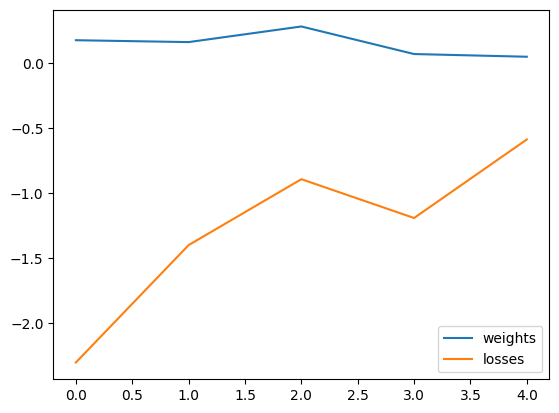

In [15]:
plt.plot(delta_weights[:5,0], label="weights")
plt.plot(delta_losses[:5],label="losses")
plt.legend()

In [5]:
from sklearn.linear_model import Lasso

clf = Lasso(fit_intercept=False)
clf.fit(delta_weights, delta_losses)

Lasso(fit_intercept=False)

In [8]:
clf.coef_

array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0.], dtype=float32)